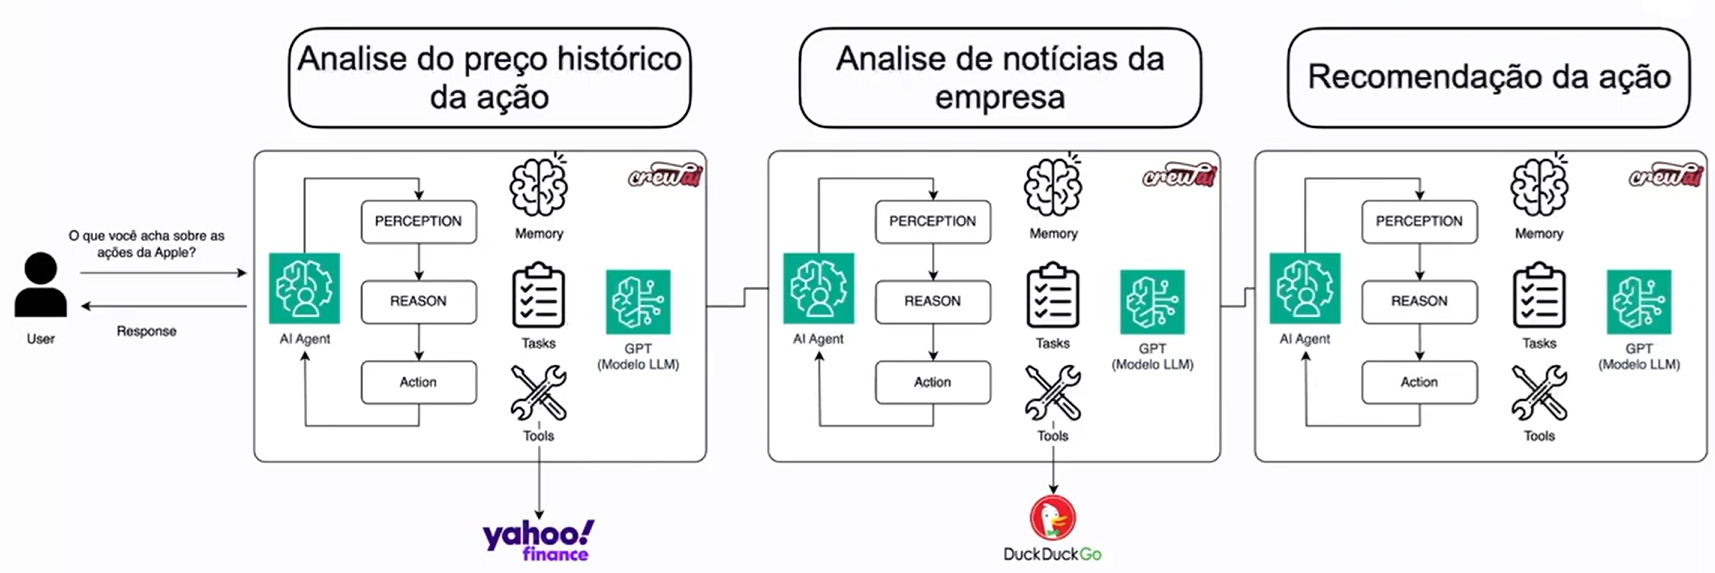

In [ ]:
# Instalação das Libs
# Diferenças em relação ao curso original:
# - Não instalamos "crewai[tools]" (o extra do crewai): ele dependia de uma versão antiga do
#   pacote lancedb que foi removida do PyPI, e nossas ferramentas customizadas não precisam dele.
# - "duckduckgo-search" foi renomeado pelo autor do pacote para "ddgs" - o langchain_community atual usa só o "ddgs" 
# - "google-genai" é necessário pra usar o Gemini como LLM (o curso original usava a OpenAI).
# - "python-dotenv" lê a chave de API do arquivo .env, em vez de escrever ela direto no código.
# (linhas comentadas porque a instalação já foi feita - descomente se recriar o ambiente do zero)
# %pip install crewai
# %pip install yfinance
# %pip install langchain-community
# %pip install ddgs
# %pip install python-dotenv
# %pip install google-genai

In [ ]:
# Import das Libs
# import os  # não é mais necessário: a chave de API agora vem do .env via load_dotenv(), não de os.environ
from datetime import datetime, timedelta

import yfinance as yf
from dotenv import load_dotenv
# load_dotenv() lê o arquivo .env com as chaves de API, evitando escrever a chave direto no código

from crewai import Agent, Task, Crew, Process, LLM
# "LLM" é a classe usada pra conectar com qualquer provedor de IA (aqui trocamos a OpenAI do curso por Gemini/Anthropic)

from crewai.tools import tool
# decorador usado pra criar ferramentas customizadas (ex: Yahoo Finance) no formato que o crewai atual exige

from langchain_community.tools import DuckDuckGoSearchResults
# utilizando o DuckDuckGo por não necessitar de criar uma conta

from IPython.display import Markdown

load_dotenv()

In [ ]:
# Quantos meses de histórico buscar no Yahoo Finance.
# Menos meses = menos texto pra IA processar (mais rápido e mais barato em tokens),
# e datas antigas demais nem ajudam tanto a avaliar a tendência ATUAL da ação.
# Aqui no notebook não tem tela pra escolher - é só editar esse número e rodar de novo.
MESES_HISTORICO = 6

# Criando Yahoo Finance Tool
# No curso original essa ferramenta era criada com Tools(name=..., description=..., func=...) do langchain
# Na versão atual, ferramentas customizadas são criadas com o decorador @tool do próprio crewai,
# aplicado direto numa função normal - o texto entre aspas triplas (docstring) vira a "descrição"
# que o agente usa pra entender quando e como usar essa ferramenta.
@tool("Yahoo Finance Tool")
def fetch_stock_price(ticket: str) -> str:
    """Busca o histórico de preço da ação (ticket) no Yahoo Finance."""
    # Datas calculadas a partir de hoje (antes eram fixas tipo "2026-01-01", e teriam que ser
    # editadas à mão todo ano). 30 dias por mês é uma aproximação simples, não precisa ser exata.
    fim = datetime.now()
    inicio = fim - timedelta(days=MESES_HISTORICO * 30)
    stock = yf.download(ticket, start=inicio.strftime("%Y-%m-%d"), end=fim.strftime("%Y-%m-%d"))
    return stock.to_string()

In [ ]:
# Configurando o LLM
# No curso original ele usa ChatOpenAI (da OpenAI), importado do langchain_openai.
# Aqui usamos a classe LLM do próprio crewai, que se conecta a vários provedores diferentes
# só trocando o texto do "model" (no formato "provedor/nome-do-modelo").
# A chave fica no arquivo .env, lida pelo load_dotenv() acima

# Opção paga (Anthropic) - precisa de ANTHROPIC_API_KEY no .env
# llm = LLM(model="anthropic/claude-sonnet-5")
# llm = LLM(model="anthropic/claude-haiku-4-5-20251001")  # versão mais barata da Anthropic

# Opções gratuitas (sem cartão de crédito) - descomente a que for usar
# llm = LLM(model="gemini/gemini-3.8-flash")  # cota gratuita bem baixa (20 req/dia) - fácil de estourar com vários agentes
llm = LLM(model="gemini/gemini-3.5-flash-lite")  # mesma chave GEMINI_API_KEY, cota bem maior (500 req/dia)
# llm = LLM(model="groq/llama-3.3-70b-versatile")  # precisa de GROQ_API_KEY no .env (console.groq.com/keys)

# Opção 100% local (sem internet, sem chave) - precisa instalar o Ollama (ollama.com) e rodar "ollama pull llama3.1" antes
# llm = LLM(model="ollama/llama3.1", base_url="http://localhost:11434")

In [ ]:
# Construção do primeiro Agent - Analista de Preços
stockPriceAnalyst = Agent(
    role = "Senior stock price Analyst",
    goal = "Find the {ticket} stock price and analyses trends",
    backstory = """You're highly experienced in analyzing the price of a specific stock
    and make predictions about its future price.""",
    verbose = True,
    llm = llm,
    max_iter = 3,
    memory = True,
    tools = [fetch_stock_price],
    allow_delegation = False,
)

In [ ]:
# Criando a tarefa que será atrelada ao Agent
getStockPrice = Task(
    description = "Analyse the stock {ticket} price history and create a trend analyses of up, down or sideways",
    expected_output = """Specify the current stock price - up, down or sideways.
    eg. stock= 'AAPL, price UP' """,
    agent = stockPriceAnalyst
)

In [ ]:
# Importando a ferramenta de pesquisa DuckDuck do langchain

# A versão atual do crewai só aceita ferramentas no formato dele (BaseTool do crewai),
# então embrulhamos a ferramenta do langchain numa função com @tool, igual fizemos com o Yahoo Finance
duckduckgo_search = DuckDuckGoSearchResults(backend='news', num_results=10)

# Criando uma ferramenta para pesquisa de Notícias
@tool("Search News Tool")
def search_tool(query: str) -> str:
    """Busca notícias recentes na internet sobre um assunto usando o DuckDuckGo."""
    return duckduckgo_search.invoke(query)

In [ ]:
# Criando Agent - Analista de Notícias
newsAnalyst = Agent(
    role = "Stock News Analyst",
    goal = """Create a short summary of the market news related to the stock {ticket} company, Specify the current trend - up, down or sideways 
    with the news context. For each request stock asset, specify a number between 0 and 100, where 0 is extreme fear and 100 is extreme greed.""",
    backstory = """You're highly experienced in analyzing the market trends and news and have tracked assets for more then 10 years.
    
    You're also master level analyst in the traditional markets and have deep understanding of human psychology.

    You understand news, theirs titles and information, but you look at those with a health dose of skepticism.
    You consider also the source of the news articles.
    """,
    verbose = True,
    llm = llm,
    max_iter = 6,
    memory = True,
    tools = [search_tool],
    allow_delegation = False,
)

In [ ]:
# Criando a Tarefa do Analista de Notícias
# description agora é uma f-string (tem o "f" antes das aspas) - sem ele, o Python não calcula
#    o datetime.now() de verdade, só mostra o texto literal "{datetime.now()}"
get_news = Task(
    description = f"""Take the stock and always include BTC to it (if not request).
    Use the search tool to search each one individually.

    The current date is {datetime.now()}.

    Compose the results into a helpfull report.
    """,
    expected_output = """A summary of the overall market and one sentence summary for each request asset.
    Include a fear/greed for each asset based on the news. Use format:
    <STOCK ASSET>
    <SUMMARY BASED ON NEWS>
    <TREND PREDICTION>
    <FEAR/GREED SCORE>
    """,
    agent = newsAnalyst
)

In [ ]:
# Criando o Agente que vai escrever a analise - Redator
stockAnalystWrite = Agent(
    role = "Senior Stock Analyst Writer",
    goal = """Analyze the trends price and write an insightful compelling and informative 3 paragraph long newsletter based on the stock report and price trend.""",
    backstory = """You're widely accepted as the best stock analyst in the market. You undertand complex concepts and create compelling stories and narratives that resonate wider audiences.
    You understand macro factors and combine multiple theories - eg. cycle theory and fundamental analyses. You're able to hold multiple opinions when analyzing.""",
    verbose = True,
    llm = llm,
    max_iter = 3,
    memory = True,
    allow_delegation = True,    
)

In [ ]:
# Criando a tarefa do Agent Redator
# "agent = stockAnalystWrite" sem colchetes - mesma correção de Task da célula anterior
writeAnalysis = Task(
    description = """Use the stock price trend and the news report to create an analyses and write the newsletter about the {ticket} company 
    that is brief and highlights the most important points.
    Focus on the stock price trend, news and fear/greed score. What are the near future considerations?
    Include the previous analyses of stock trend and news summary.""",
    expected_output = """
    - A title for the article
    - Introduction - set the overall picture and spike up the interest in one paragraph
    - A subtitle with 3 bullets executive summary
    - Another paragraph
    - Another subtitle with 3 bullets main analysis
    - Main part provies the meat of the analysis including the news summary and fear/greed scores
    - Summary - key facts concrete future trend prediction - up, down or sideways.
    """,
    agent = stockAnalystWrite,
    context = [getStockPrice, get_news]
)

In [ ]:
# Criando o grupo de Agentes
# full_output, share_crew e max_iter (neste nível) não existem mais nas versões atuais do crewai

crew = Crew(
    agents = [stockPriceAnalyst, newsAnalyst, stockAnalystWrite],
    tasks = [getStockPrice, get_news, writeAnalysis],
    verbose = True,
    process = Process.hierarchical,
    manager_llm = llm,
)

In [ ]:
# Com a equipe de agentes pronta, agora basta executar
# O Jupyter já roda um "event loop" por baixo dos panos, entao usamos a versão assíncrona (kickoff_async) junto com await
results = await crew.kickoff_async(inputs={'ticket': 'AAPL'})

In [ ]:
# Ver o resultado final
# .raw no lugar de ['final_output'] (resultado agora é objeto, não dicionário - ver célula anterior)
results.raw

In [ ]:
# Gerar a saída final em formato Markdown
# results.raw no lugar de results['final_outputs'] (o original também tinha um "s" a mais, de digitação)
Markdown(results.raw)